# Recommender System - Benzer İsim Öneri Sistemi

Öneri sistemleri kullanıcıya benzer ürün/içerik önerir. Bu projede bir bebek ismi seçildiğinde yıllar içindeki popülerlik eğrisi en çok benzeyen isimleri öneriyoruz (content-based / benzerlik tabanlı).

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import glob, os

dosyalar = sorted(glob.glob('yob*.txt'))
len(dosyalar)

146

In [3]:
parcalar=[]
for d in dosyalar:
    t=pd.read_csv(d,names=['name','sex','count'])
    t['year']=int(os.path.basename(d)[3:7])
    parcalar.append(t)
df=pd.concat(parcalar)

In [4]:
df=df[df['year']>=1950]
pivot=df.groupby(['name','year'])['count'].sum().unstack(fill_value=0)
en_populer=pivot.sum(axis=1).sort_values(ascending=False).head(3000).index
pivot=pivot.loc[en_populer]

In [5]:
pivot.shape

(3000, 76)

Her ismin yıllara göre dağılımını oranlıyoruz (toplamı 1). Böylece çok popüler ve az popüler isimler eğrinin **şekline** göre karşılaştırılır.

In [6]:
oran=pivot.div(pivot.sum(axis=1),axis=0)

In [7]:
from sklearn.neighbors import NearestNeighbors
nn=NearestNeighbors(metric='cosine',algorithm='brute')
nn.fit(oran.values)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [8]:
def oner(isim,n=5):
    idx=list(oran.index).index(isim)
    uzaklik,indeks=nn.kneighbors(oran.iloc[[idx]].values,n_neighbors=n+1)
    sonuc=pd.DataFrame({'isim':oran.index[indeks[0][1:]],'benzerlik':1-uzaklik[0][1:]})
    return sonuc

In [9]:
oner(oran.index[0])

,isim,benzerlik
0,Phillip,0.992740
1,Terrence,0.990719
2,Danial,0.990040
3,Antoinette,0.988861
4,Michel,0.987866


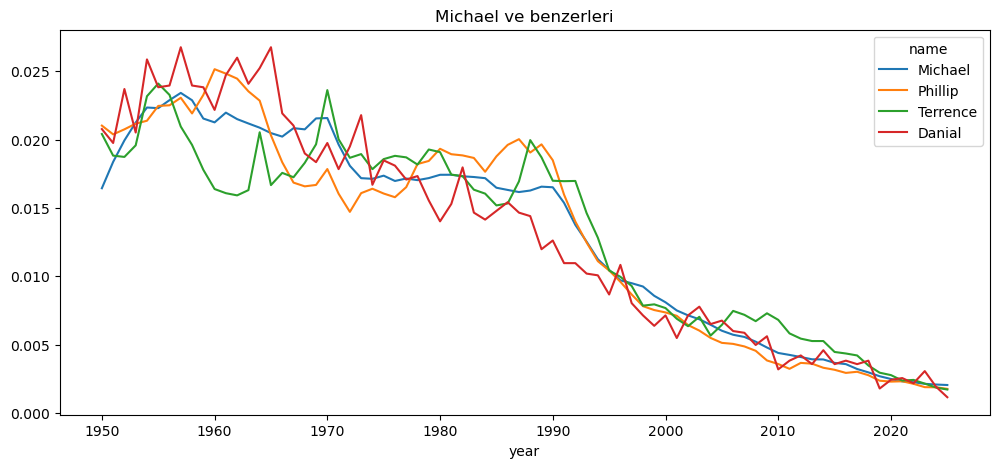

In [10]:
ornek=oran.index[0]
benzer=oner(ornek,3)['isim'].tolist()
oran.loc[[ornek]+benzer].T.plot(figsize=(12,5),title=f'{ornek} ve benzerleri');

In [11]:
import pickle
pickle.dump(nn,open('isim_nn.pkl','wb'))
pickle.dump(oran,open('isim_oran.pkl','wb'))